### Power transformer
1. Box-Cox Transformation
2. Yeo-Johnson Transformation

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

In [51]:

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats

In [52]:
df =pd.read_csv('concrete_data.csv')
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [53]:
x = df.drop(columns=['Strength'])
y =df.iloc[:,-1]

In [54]:
x_train ,x_test ,y_train, y_test = train_test_split(x,y ,test_size=.2,random_state=42)
x_train.shape,x_test.shape

((824, 8), (206, 8))

In [55]:
x_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28


 Applying Regression without any transformation

In [56]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred =lr.predict(x_test)
r2_score(y_test,y_pred)


0.6275531792314851

Cross checking with cross val score

In [57]:
lr1 = LinearRegression()
np.mean(cross_val_score(lr1,x,y,scoring='r2'))

np.float64(0.4609940491662865)

Plotting the distplots without any transformation

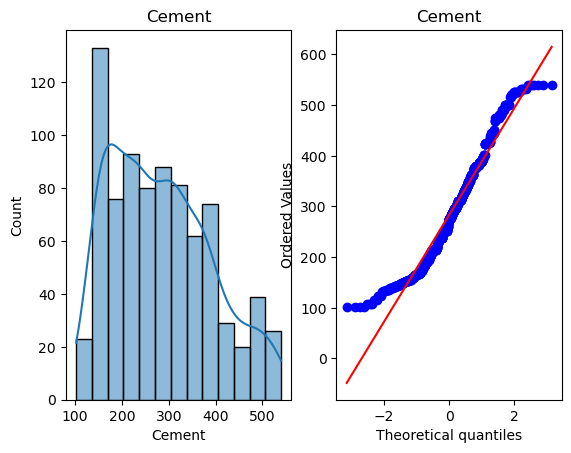

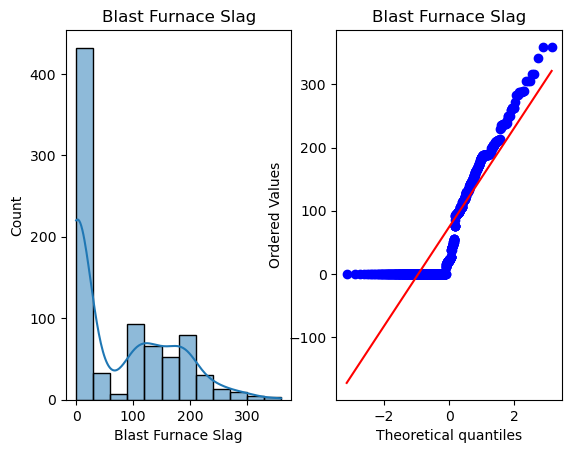

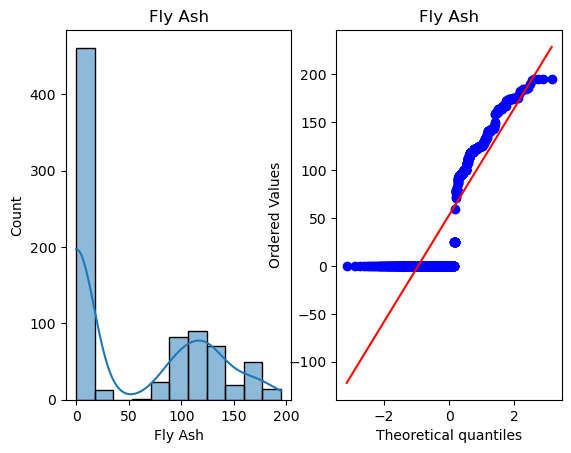

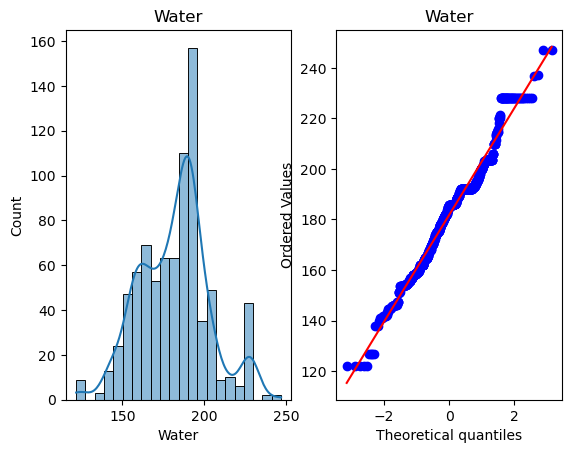

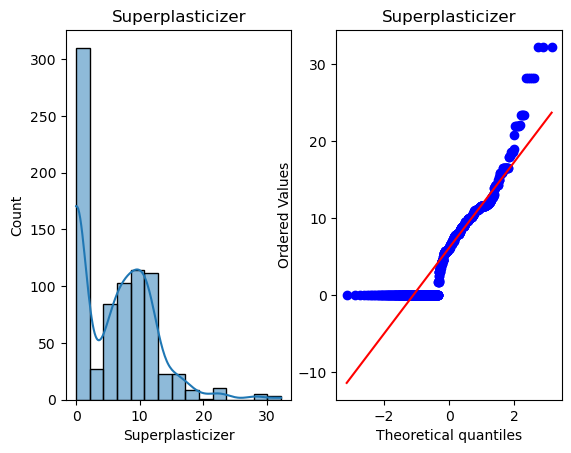

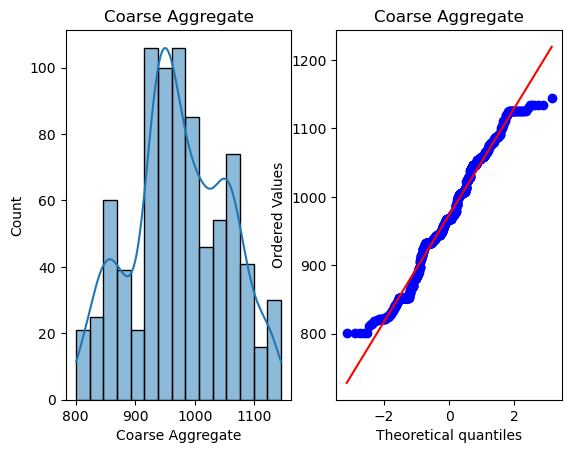

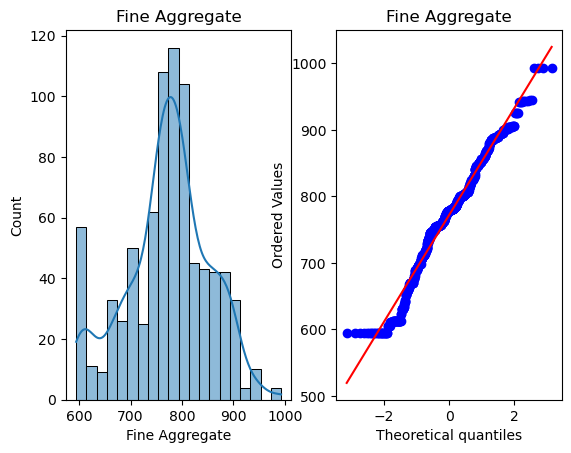

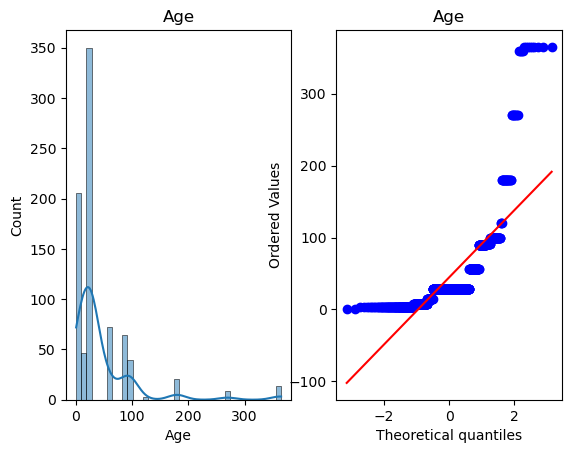

In [ ]:
for col in x_train.columns:
    plt.Figure(figsize=(14,20))
    plt.subplot(1,2,1)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x_train[col],plot=plt, dist='norm')
    plt.title(col)

    plt.show()
    


In [59]:
# Applying Box-Cox Transform
trf = PowerTransformer(method='box-cox')
x_train_trans = trf.fit_transform(x_train+.00000001)
x_test_trans = trf.transform(x_test+.0000001)


In [60]:
# Applying linear regression on transformed data
lr2 = LinearRegression()
lr2.fit(x_train_trans,y_train)
y_pred2= lr2.predict(x_test_trans)
r2_score(y_test,y_pred2)


0.8068697781450452

In [61]:
#  using cross_val_score
pt =PowerTransformer(method='box-cox')
x_transformed = pt.fit_transform(x+.0000001)
lr = LinearRegression() 
np.mean(cross_val_score(lr,x_transformed,y ,scoring='r2'))

np.float64(0.6658537941434355)

In [62]:
x_train_trans =pd.DataFrame(x_train_trans,columns=x_train.columns)

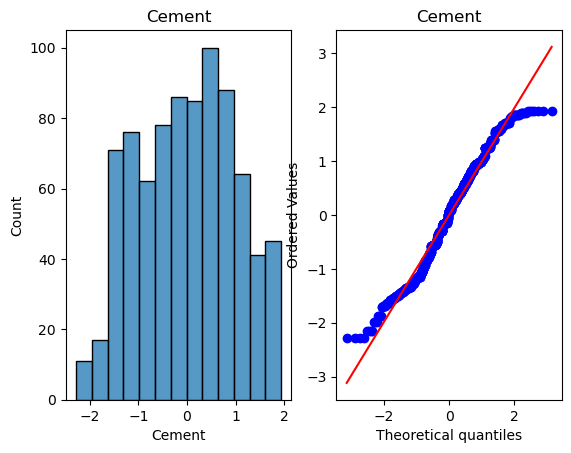

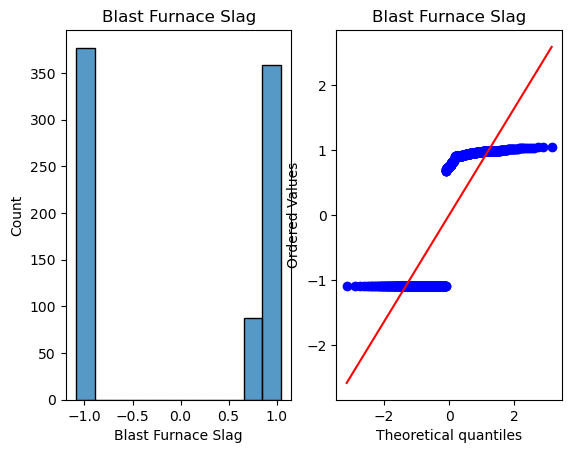

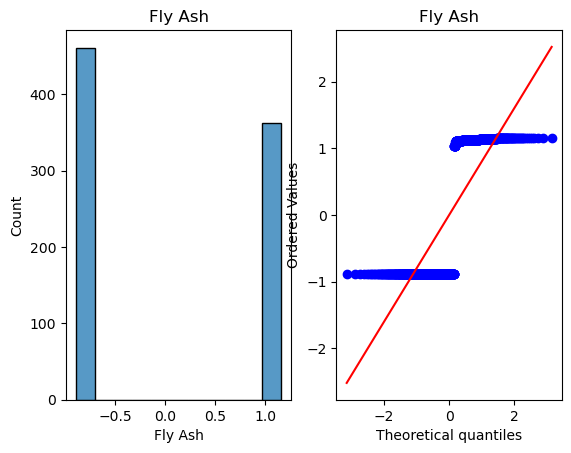

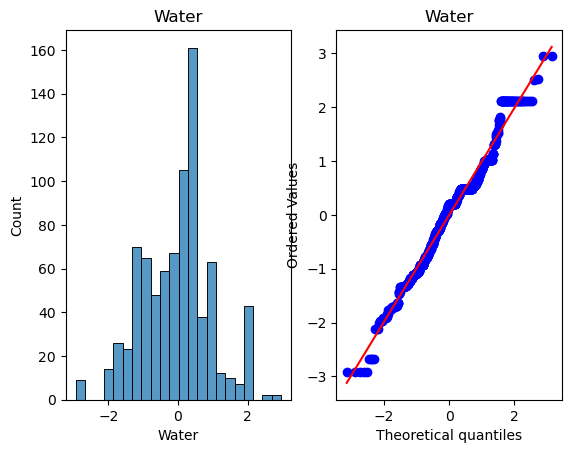

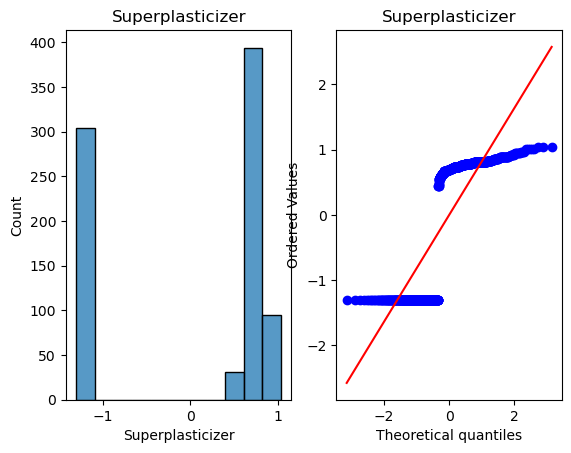

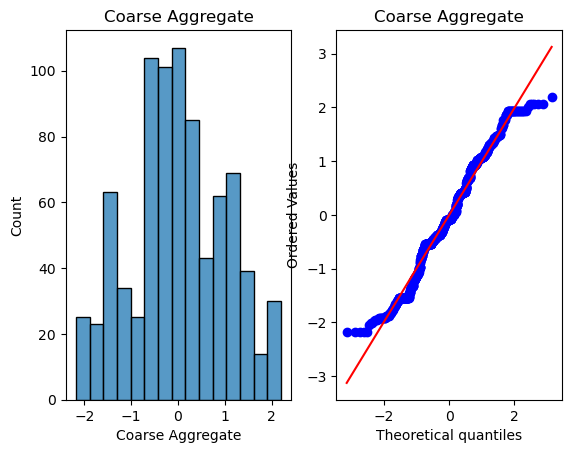

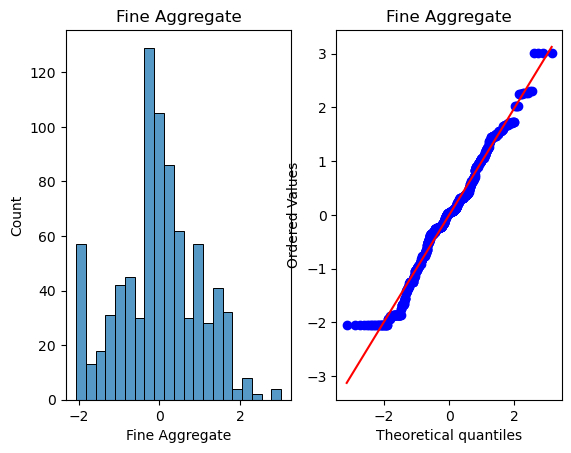

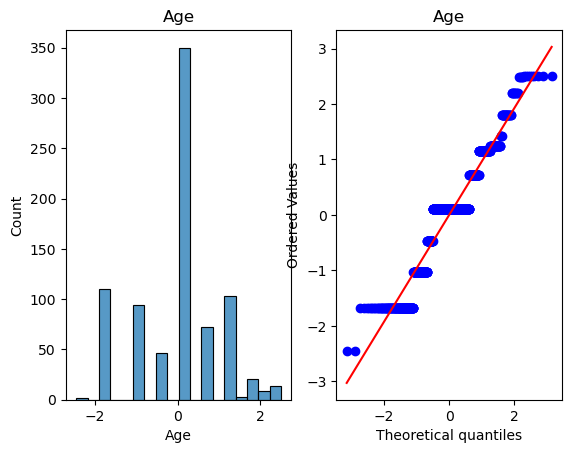

In [71]:
for col in x_train_trans.columns:
    plt.Figure(figsize=(22,22))
    plt.subplot(1,2,1)
    sns.histplot(x_train_trans[col])
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x_train_trans[col],plot=plt,dist='norm')
    plt.title(col)

    plt.show()
    

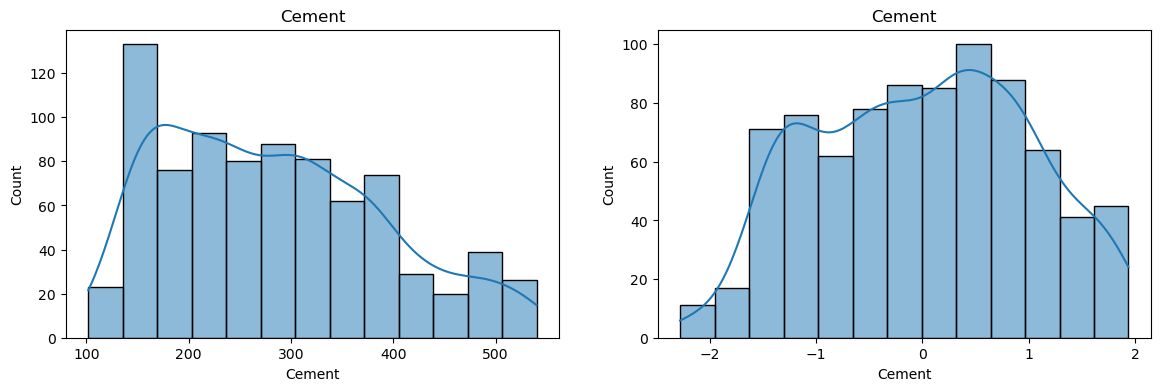

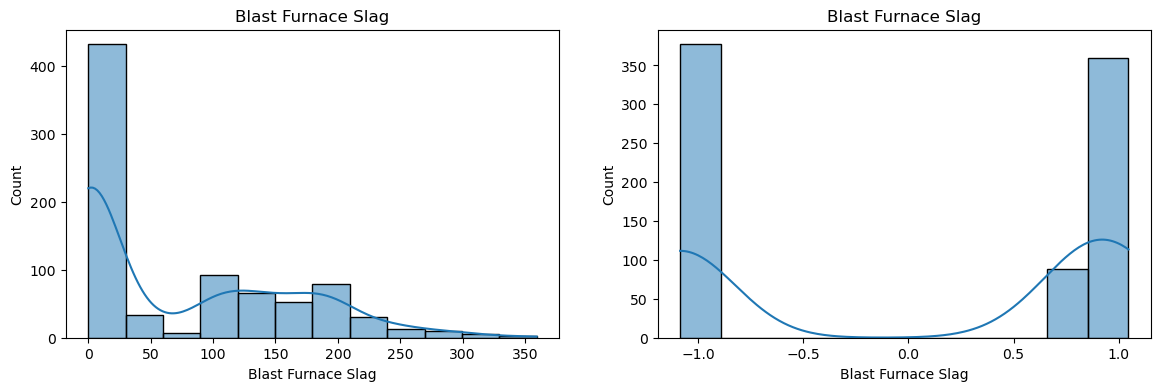

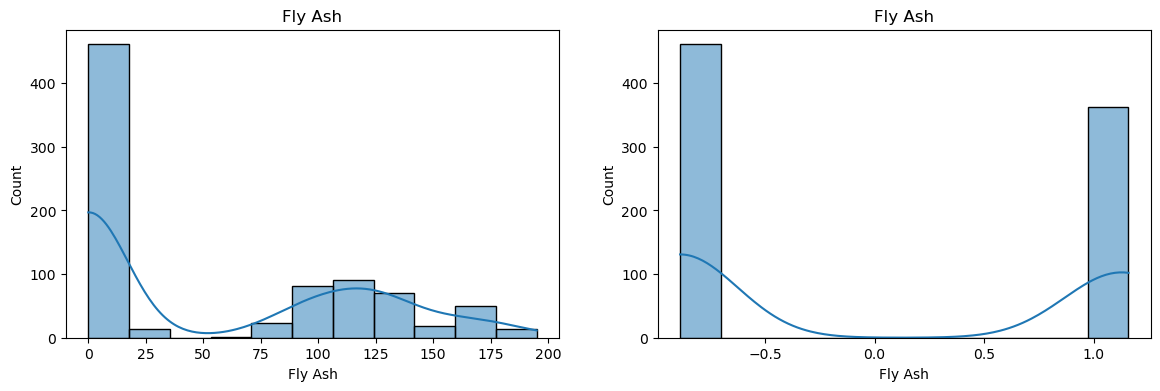

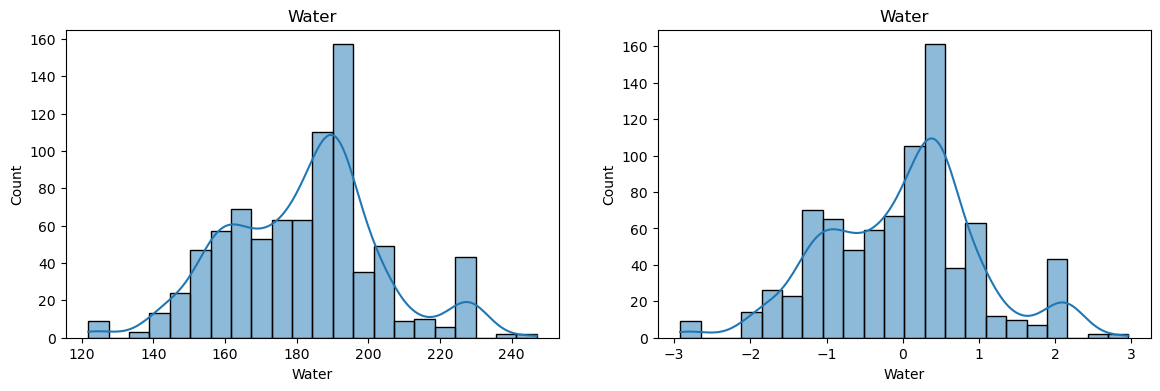

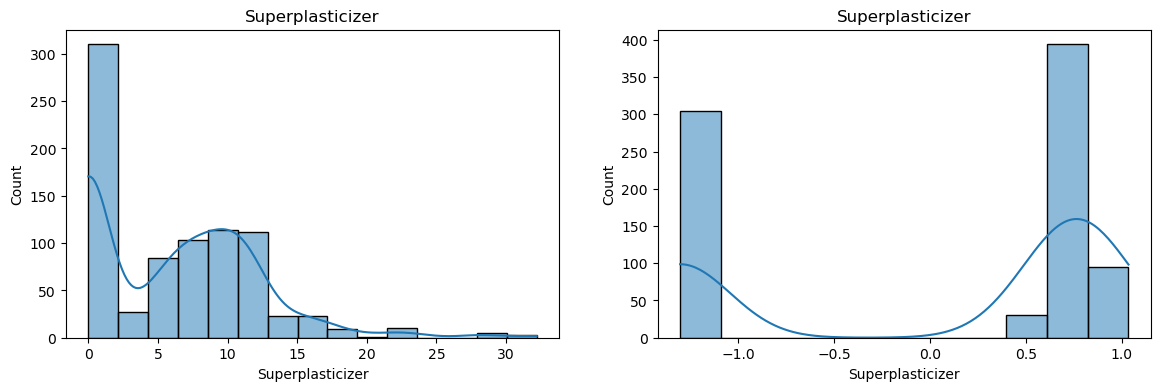

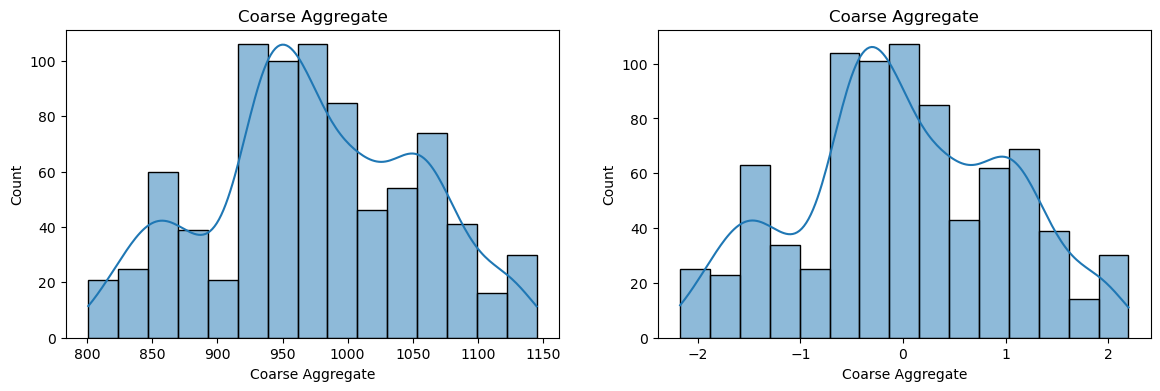

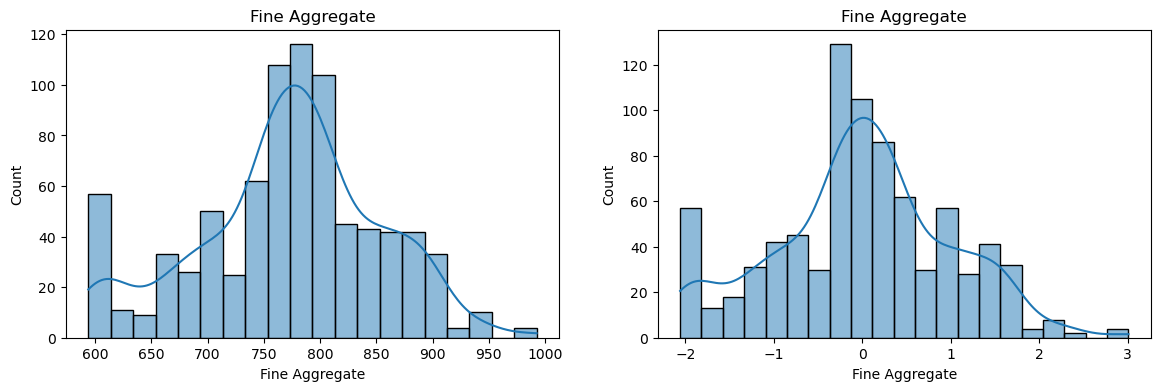

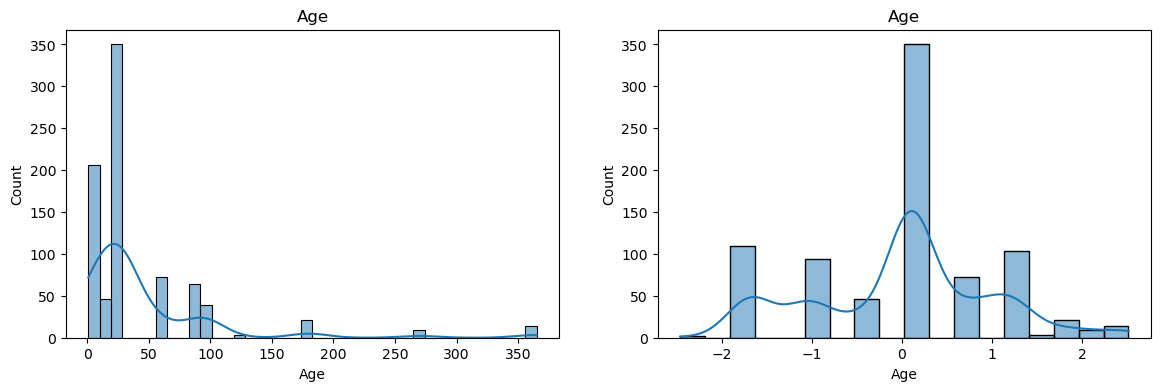

In [74]:
# Before and after comparision for Box-Cox Plot

for col in x_train_trans.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_trans[col],kde=True)
    plt.title(col)

    plt.show()

In [76]:
# Apply Yeo-Johnson transform
pt = PowerTransformer(method='yeo-johnson')
x_train_transform =pt.fit_transform(x_train)
x_test_transformed =pt.transform(x_test)

# appling  linearregression
lr = LinearRegression()
lr.fit(x_train_transform,y_train)
y_prediction = lr.predict(x_test_transformed)
r2_score(y_test,y_prediction)

0.8161906511066098

In [78]:
pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas':pt.lambdas_})

,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [80]:
#  appling cross_val_score
pty = PowerTransformer(method='yeo-johnson')
x_trans = pty.fit_transform(x)

lr=LinearRegression()

np.mean(cross_val_score(lr,x_trans,y,scoring='r2',cv=10))




np.float64(0.6586548619389643)